# NeuroPilot: EEG Based Brain State Classifier

This project uses public EEG brain signal data to classify imagined left hand movement versus imagined right hand movement.

## Tools Used

- MNE Python
- Scikit learn
- Google Colab
- Public EEGBCI dataset

## Project Abstract

NeuroPilot is a beginner neurotechnology project that uses public EEG recordings to classify imagined left hand movement versus imagined right hand movement. Using MNE Python, I loaded EEG recordings from the EEGBCI dataset, filtered the signals between 7 and 30 Hz, segmented the data into motor imagery epochs, extracted spatial EEG features using Common Spatial Patterns, and trained machine learning classifiers to predict imagined movement type.

The project compared single subject classification, multi subject classification, subject specific cross validation, classifier comparison, and leave one subject out testing. The strongest result came from Subject 2, which reached 86.67 percent mean cross validated accuracy. However, leave one subject out testing performed much worse, showing that EEG models struggled to generalize to unseen participants.

Overall, NeuroPilot shows that EEG based motor imagery classification is possible using free public data, but performance depends strongly on individual calibration.

## Methods

This project used public EEG recordings from the EEGBCI motor imagery dataset.
The analysis focused on runs 4, 8, and 12, which contain imagined left hand movement and imagined right hand movement tasks. EEG signals were loaded using MNE Python, standardized, assigned electrode locations, and filtered between 7 and 30 Hz. The filtered signals were divided into epochs from 1 to 4 seconds after each task cue. Common Spatial Patterns was used to extract spatial EEG features, and machine learning classifiers were trained to predict the imagined movement condition. The project tested logistic regression and support vector machine classifiers using train test splitting, cross validation, and leave one subject out evaluation.

In [ ]:
!pip install mne scikit-learn matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 59.6 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
!pip install mne scikit-learn matplotlib numpy

In [5]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.decoding import CSP

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
subject = 1
runs = [4, 8, 12]

files = eegbci.load_data(subject, runs)
raws = [read_raw_edf(f, preload=True) for f in files]
raw = concatenate_raws(raws)

raw

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m13s (7.4 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Re

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>

In [7]:
eegbci.standardize(raw)
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)

raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

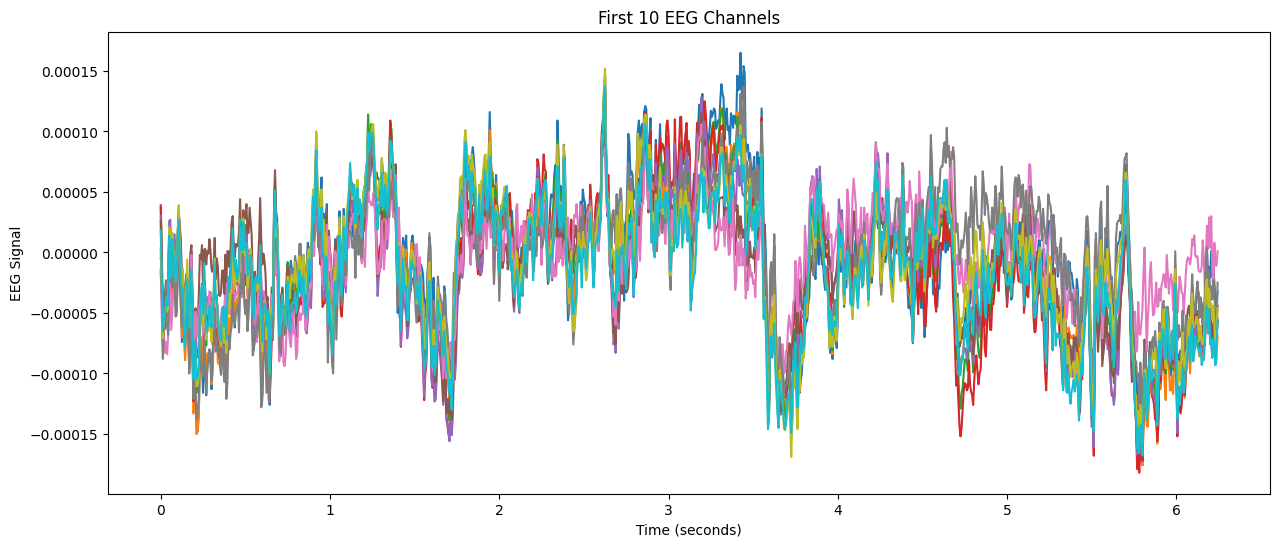

In [8]:
data, times = raw[:10, :1000]

plt.figure(figsize=(15, 6))
plt.plot(times, data.T)
plt.xlabel("Time (seconds)")
plt.ylabel("EEG Signal")
plt.title("First 10 EEG Channels")
plt.show()

In [9]:
raw.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

In [10]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)
print(events[:10])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [12]:
event_id = dict(left=2, right=3)

tmin, tmax = 1.0, 4.0

epochs = mne.Epochs(
    raw,
    events,
    event_id,
    tmin,
    tmax,
    proj=True,
    baseline=None,
    preload=True
)

epochs

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 481 original time points ...
0 bad epochs dropped


<Epochs | 45 events (all good), 1 – 4 s (baseline off), ~10.6 MiB, data loaded,
 'left': 23
 'right': 22>

In [13]:
X = epochs.get_data()
y = epochs.events[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y))

X shape: (45, 64, 481)
y shape: (45,)
Labels: [2 3]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (33, 64, 481)
Testing data: (12, 64, 481)


In [16]:
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

clf = Pipeline([
    ("CSP", csp),
    ("LogisticRegression", LogisticRegression(max_iter=1000))
])

In [17]:
clf.fit(X_train, y_train)

Computing rank from data with rank=None
    Using tolerance 0.00024 (2.2e-16 eps * 64 dim * 1.7e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.


Pipeline(steps=[('CSP', CSP(log=True)),
                ('LogisticRegression', LogisticRegression(max_iter=1000))])

In [18]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, y_pred, target_names=["Left Imagery", "Right Imagery"]))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 66.67 %

               precision    recall  f1-score   support

 Left Imagery       0.62      0.83      0.71         6
Right Imagery       0.75      0.50      0.60         6

     accuracy                           0.67        12
    macro avg       0.69      0.67      0.66        12
 weighted avg       0.69      0.67      0.66        12


Confusion Matrix:
[[5 1]
 [3 3]]


In [19]:
sample_index = 0

sample = X_test[sample_index:sample_index+1]
prediction = clf.predict(sample)[0]
actual = y_test[sample_index]

label_map = {
    2: "Imagined Left Hand Movement",
    3: "Imagined Right Hand Movement"
}

print("Actual:", label_map[actual])
print("Prediction:", label_map[prediction])

Actual: Imagined Left Hand Movement
Prediction: Imagined Left Hand Movement


## NeuroPilot v1 Summary

This project built a basic EEG based brain state classifier using public EEG recordings.

The model classified imagined left hand movement versus imagined right hand movement using 64 EEG channels.

The workflow included signal filtering, event extraction, epoch creation, CSP feature extraction, and logistic regression classification.

The first version achieved 66.67 percent accuracy on one subject.

## NeuroPilot v2: Multi Subject EEG Classifier

In this version, I expanded the project from one subject to multiple subjects.

This gives the model more EEG examples to learn from and makes the project more realistic.

In [20]:
subjects = [1, 2, 3, 4, 5]
runs = [4, 8, 12]

all_raws = []

for subject in subjects:
    print("Loading subject:", subject)

    files = eegbci.load_data(subject, runs)
    subject_raws = [read_raw_edf(f, preload=True) for f in files]
    subject_raw = concatenate_raws(subject_raws)

    eegbci.standardize(subject_raw)
    subject_raw.set_montage(montage)

    all_raws.append(subject_raw)

raw_multi = concatenate_raws(all_raws)

raw_multi

Loading subject: 1
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading subject: 2


Download complete in 30s (7.3 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Loading subject: 3


Download complete in 30s (7.4 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S003/S003R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S003/S003R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S003/S003R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading subject: 4


Download complete in 32s (7.3 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S004/S004R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S004/S004R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S004/S004R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Loading subject: 5


Download complete in 30s (7.3 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S005/S005R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S005/S005R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S005/S005R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...


<RawEDF | S001R04.edf, 64 x 297120 (1857.0 s), ~145.2 MiB, data loaded>

In [21]:
raw_multi.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

Filtering raw data in 15 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R04.edf, 64 x 297120 (1857.0 s), ~145.2 MiB, data loaded>

In [22]:
events_multi, event_id_multi = mne.events_from_annotations(raw_multi)

print(event_id_multi)
print(events_multi[:10])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [23]:
event_id = dict(left=2, right=3)

tmin, tmax = 1.0, 4.0

epochs_multi = mne.Epochs(
    raw_multi,
    events_multi,
    event_id,
    tmin,
    tmax,
    proj=True,
    baseline=None,
    preload=True
)

epochs_multi

Not setting metadata
225 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 225 events and 481 original time points ...
0 bad epochs dropped


<Epochs | 225 events (all good), 1 – 4 s (baseline off), ~52.9 MiB, data loaded,
 'left': 113
 'right': 112>

In [24]:
X_multi = epochs_multi.get_data()
y_multi = epochs_multi.events[:, -1]

print("X shape:", X_multi.shape)
print("y shape:", y_multi.shape)
print("Labels:", np.unique(y_multi))

X shape: (225, 64, 481)
y shape: (225,)
Labels: [2 3]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.25,
    random_state=42,
    stratify=y_multi
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (168, 64, 481)
Testing data: (57, 64, 481)


In [26]:
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

clf_multi = Pipeline([
    ("CSP", csp),
    ("LogisticRegression", LogisticRegression(max_iter=1000))
])

clf_multi.fit(X_train, y_train)

Computing rank from data with rank=None
    Using tolerance 0.00042 (2.2e-16 eps * 64 dim * 3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.


Pipeline(steps=[('CSP', CSP(log=True)),
                ('LogisticRegression', LogisticRegression(max_iter=1000))])

In [27]:
y_pred = clf_multi.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, y_pred, target_names=["Left Imagery", "Right Imagery"]))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 52.63 %

               precision    recall  f1-score   support

 Left Imagery       0.53      0.69      0.60        29
Right Imagery       0.53      0.36      0.43        28

     accuracy                           0.53        57
    macro avg       0.53      0.52      0.51        57
 weighted avg       0.53      0.53      0.51        57


Confusion Matrix:
[[20  9]
 [18 10]]


In [28]:
for n in [2, 4, 6, 8, 10]:
    csp = CSP(n_components=n, reg=None, log=True, norm_trace=False)

    clf_test = Pipeline([
        ("CSP", csp),
        ("LogisticRegression", LogisticRegression(max_iter=1000))
    ])

    clf_test.fit(X_train, y_train)
    y_pred = clf_test.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("CSP components:", n, "Accuracy:", round(acc * 100, 2), "%")

Computing rank from data with rank=None
    Using tolerance 0.00042 (2.2e-16 eps * 64 dim * 3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
CSP components: 2 Accuracy: 49.12 %
Computing rank from data with rank=None
    Using tolerance 0.00042 (2.2e-16 eps * 64 dim * 3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
CSP components: 4 Accuracy: 52.63 %
Computing rank from data with rank=None
    Using tolerance 0.00042 (2.2e-16 eps * 64 dim * 3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reduci

In [29]:
csp = CSP(n_components=6, reg="ledoit_wolf", log=True, norm_trace=False)

clf_reg = Pipeline([
    ("CSP", csp),
    ("LogisticRegression", LogisticRegression(max_iter=1000))
])

clf_reg.fit(X_train, y_train)

y_pred = clf_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Regularized CSP Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, y_pred, target_names=["Left Imagery", "Right Imagery"]))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Computing rank from data with rank=None
    Using tolerance 0.00042 (2.2e-16 eps * 64 dim * 3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Regularized CSP Accuracy: 47.37 %

               precision    recall  f1-score   support

 Left Imagery       0.49      0.59      0.53        29
Right Imagery       0.45      0.36      0.40        28

     accuracy                           0.47        57
    macro avg       0.47      0.47      0.47        57
 weighted avg       0.47      0.47      0.47        57


Confusion Matrix:
[[17 12]
 [18 10]]


## NeuroPilot v3: Subject Specific Model Comparison

In this version, I tested each subject separately to see whether EEG classification performs better when the model is trained on one person's brain signals at a time.

This is important because EEG patterns can vary between individuals.

In [30]:
subjects = [1, 2, 3, 4, 5]
runs = [4, 8, 12]

subject_results = []

for subject in subjects:
    print("\nTesting subject:", subject)

    files = eegbci.load_data(subject, runs)
    raws = [read_raw_edf(f, preload=True) for f in files]
    raw_subject = concatenate_raws(raws)

    eegbci.standardize(raw_subject)
    raw_subject.set_montage(montage)
    raw_subject.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

    events_subject, event_id_subject = mne.events_from_annotations(raw_subject)

    epochs_subject = mne.Epochs(
        raw_subject,
        events_subject,
        dict(left=2, right=3),
        tmin=1.0,
        tmax=4.0,
        proj=True,
        baseline=None,
        preload=True
    )

    X_subject = epochs_subject.get_data()
    y_subject = epochs_subject.events[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X_subject,
        y_subject,
        test_size=0.25,
        random_state=42,
        stratify=y_subject
    )

    csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

    clf_subject = Pipeline([
        ("CSP", csp),
        ("LogisticRegression", LogisticRegression(max_iter=1000))
    ])

    clf_subject.fit(X_train, y_train)
    y_pred = clf_subject.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    subject_results.append([subject, round(acc * 100, 2)])

    print("Accuracy:", round(acc * 100, 2), "%")


Testing subject: 1
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband atte

In [31]:
import pandas as pd

results_df = pd.DataFrame(subject_results, columns=["Subject", "Accuracy (%)"])
results_df

,Subject,Accuracy (%)
0,1,66.67
1,2,91.67
2,3,50.00
3,4,66.67
4,5,58.33


## NeuroPilot v3 Results

The subject specific comparison showed that EEG classification accuracy varied strongly between participants.

Subject 2 achieved the highest accuracy at 91.67 percent, while Subject 3 performed near chance level at 50.00 percent.

This suggests that motor imagery EEG classification works better for some individuals than others, and that subject specific models may be more effective than a single combined multi subject model.

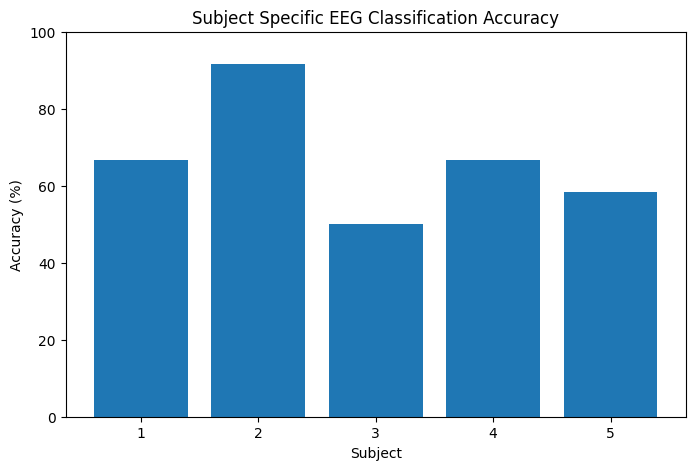

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Subject"], results_df["Accuracy (%)"])
plt.xlabel("Subject")
plt.ylabel("Accuracy (%)")
plt.title("Subject Specific EEG Classification Accuracy")
plt.ylim(0, 100)
plt.show()

## NeuroPilot v4: Cross Validated Subject Specific Accuracy

In this version, I used 5 fold cross validation to get a more reliable estimate of classification accuracy for each subject.

Instead of testing the model once, cross validation trains and tests the model multiple times on different splits of the data.

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

subjects = [1, 2, 3, 4, 5]
runs = [4, 8, 12]

cv_results = []

for subject in subjects:
    print("\nCross validating subject:", subject)

    files = eegbci.load_data(subject, runs)
    raws = [read_raw_edf(f, preload=True) for f in files]
    raw_subject = concatenate_raws(raws)

    eegbci.standardize(raw_subject)
    raw_subject.set_montage(montage)
    raw_subject.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

    events_subject, event_id_subject = mne.events_from_annotations(raw_subject)

    epochs_subject = mne.Epochs(
        raw_subject,
        events_subject,
        dict(left=2, right=3),
        tmin=1.0,
        tmax=4.0,
        proj=True,
        baseline=None,
        preload=True
    )

    X_subject = epochs_subject.get_data()
    y_subject = epochs_subject.events[:, -1]

    csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

    clf_subject = Pipeline([
        ("CSP", csp),
        ("LogisticRegression", LogisticRegression(max_iter=1000))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(clf_subject, X_subject, y_subject, cv=cv)

    mean_score = round(scores.mean() * 100, 2)
    std_score = round(scores.std() * 100, 2)

    cv_results.append([subject, mean_score, std_score])

    print("Scores:", np.round(scores * 100, 2))
    print("Mean accuracy:", mean_score, "%")
    print("Standard deviation:", std_score, "%")


Cross validating subject: 1
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stop

In [34]:
cv_results_df = pd.DataFrame(
    cv_results,
    columns=["Subject", "Mean Accuracy (%)", "Standard Deviation (%)"]
)

cv_results_df

,Subject,Mean Accuracy (%),Standard Deviation (%)
0,1,71.11,5.44
1,2,86.67,10.89
2,3,64.44,16.33
3,4,53.33,8.31
4,5,62.22,8.89


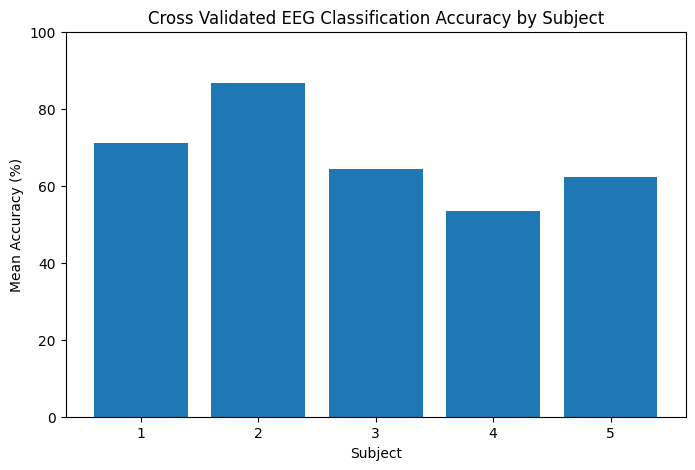

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(cv_results_df["Subject"], cv_results_df["Mean Accuracy (%)"])
plt.xlabel("Subject")
plt.ylabel("Mean Accuracy (%)")
plt.title("Cross Validated EEG Classification Accuracy by Subject")
plt.ylim(0, 100)
plt.show()

## NeuroPilot v4 Results

The cross validated results showed that subject specific EEG classification remained above chance for most participants.

Subject 2 had the strongest performance, with a mean accuracy of 86.67 percent.

Subject 1 also performed well, with a mean accuracy of 71.11 percent.

Subject 4 was close to chance level at 53.33 percent, suggesting that motor imagery EEG patterns were harder to classify for that participant.

Overall, the cross validation results support the idea that EEG motor imagery classification can work well for some individuals, but performance varies strongly between subjects.

## NeuroPilot v5: Classifier Comparison

In this version, I compared logistic regression with a support vector machine classifier to see whether a different machine learning model improves EEG classification accuracy.

In [36]:
from sklearn.svm import SVC

subjects = [1, 2, 3, 4, 5]
runs = [4, 8, 12]

model_comparison_results = []

for subject in subjects:
    print("\nTesting subject:", subject)

    files = eegbci.load_data(subject, runs)
    raws = [read_raw_edf(f, preload=True) for f in files]
    raw_subject = concatenate_raws(raws)

    eegbci.standardize(raw_subject)
    raw_subject.set_montage(montage)
    raw_subject.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

    events_subject, event_id_subject = mne.events_from_annotations(raw_subject)

    epochs_subject = mne.Epochs(
        raw_subject,
        events_subject,
        dict(left=2, right=3),
        tmin=1.0,
        tmax=4.0,
        proj=True,
        baseline=None,
        preload=True
    )

    X_subject = epochs_subject.get_data()
    y_subject = epochs_subject.events[:, -1]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM": SVC(kernel="linear")
    }

    for model_name, model in models.items():
        csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

        clf = Pipeline([
            ("CSP", csp),
            (model_name, model)
        ])

        scores = cross_val_score(clf, X_subject, y_subject, cv=cv)

        mean_score = round(scores.mean() * 100, 2)
        std_score = round(scores.std() * 100, 2)

        model_comparison_results.append([
            subject,
            model_name,
            mean_score,
            std_score
        ])

        print(model_name, "Mean accuracy:", mean_score, "%")


Testing subject: 1
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband atte

In [37]:
model_comparison_df = pd.DataFrame(
    model_comparison_results,
    columns=["Subject", "Model", "Mean Accuracy (%)", "Standard Deviation (%)"]
)

model_comparison_df

,Subject,Model,Mean Accuracy (%),Standard Deviation (%)
0,1,Logistic Regression,71.11,5.44
1,1,SVM,73.33,8.89
2,2,Logistic Regression,86.67,10.89
3,2,SVM,86.67,12.96
4,3,Logistic Regression,64.44,16.33
5,3,SVM,53.33,8.31
6,4,Logistic Regression,53.33,8.31
7,4,SVM,53.33,12.96
8,5,Logistic Regression,62.22,8.89
9,5,SVM,66.67,9.94


## NeuroPilot v5 Results

The classifier comparison showed that SVM and logistic regression performed similarly overall.

SVM slightly improved performance for Subject 1 and Subject 5, while both models tied for Subject 2 and Subject 4.

Logistic regression performed better for Subject 3.

The best overall result remained Subject 2, where both models achieved 86.67 percent mean cross validated accuracy.

These results suggest that model choice can affect EEG classification performance, but subject specific differences remain the biggest factor.

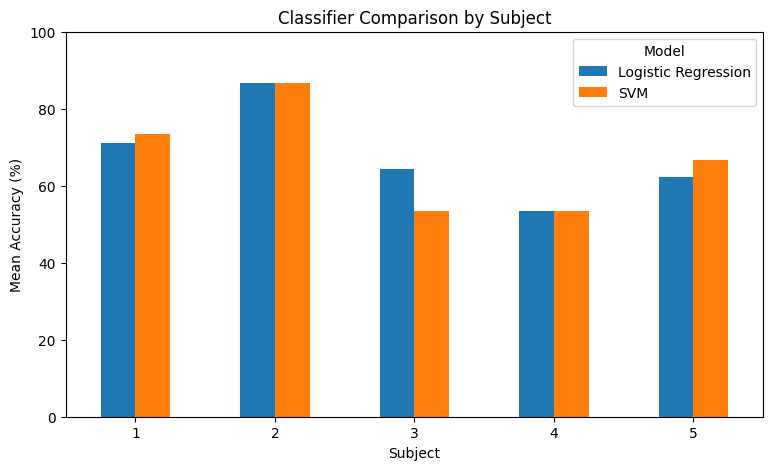

In [38]:
import numpy as np

pivot_df = model_comparison_df.pivot(
    index="Subject",
    columns="Model",
    values="Mean Accuracy (%)"
)

pivot_df.plot(kind="bar", figsize=(9, 5))
plt.xlabel("Subject")
plt.ylabel("Mean Accuracy (%)")
plt.title("Classifier Comparison by Subject")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

## Extra Visualization: Cross Validated Results with Error Bars

This graph shows the mean cross validated accuracy for each subject, with standard deviation shown as error bars.

The error bars help show how consistent or variable the model was across different train test splits.

Smaller error bars suggest more stable performance, while larger error bars suggest that the model’s accuracy changed more depending on the split.

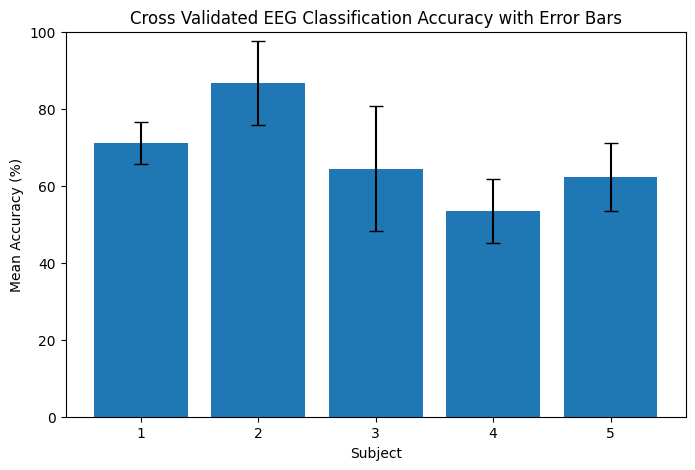

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results_df["Subject"],
    cv_results_df["Mean Accuracy (%)"],
    yerr=cv_results_df["Standard Deviation (%)"],
    capsize=5
)

plt.xlabel("Subject")
plt.ylabel("Mean Accuracy (%)")
plt.title("Cross Validated EEG Classification Accuracy with Error Bars")
plt.ylim(0, 100)
plt.show()

## NeuroPilot v6: Leave One Subject Out Testing

In this version, I tested whether the model could generalize to a completely unseen participant.

For each test, the classifier was trained on four subjects and tested on the remaining subject.

This is a harder and more realistic test because the model has to classify EEG patterns from a person it has never seen before.

In [40]:
subjects = [1, 2, 3, 4, 5]
runs = [4, 8, 12]

subject_data = {}

for subject in subjects:
    print("Loading subject:", subject)

    files = eegbci.load_data(subject, runs)
    raws = [read_raw_edf(f, preload=True) for f in files]
    raw_subject = concatenate_raws(raws)

    eegbci.standardize(raw_subject)
    raw_subject.set_montage(montage)
    raw_subject.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

    events_subject, event_id_subject = mne.events_from_annotations(raw_subject)

    epochs_subject = mne.Epochs(
        raw_subject,
        events_subject,
        dict(left=2, right=3),
        tmin=1.0,
        tmax=4.0,
        proj=True,
        baseline=None,
        preload=True
    )

    X_subject = epochs_subject.get_data()
    y_subject = epochs_subject.events[:, -1]

    subject_data[subject] = (X_subject, y_subject)

print("Finished loading all subject data.")

Loading subject: 1
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband atten

In [41]:
loso_results = []

for test_subject in subjects:
    print("\nTesting on unseen subject:", test_subject)

    X_train_list = []
    y_train_list = []

    for train_subject in subjects:
        if train_subject != test_subject:
            X_train_list.append(subject_data[train_subject][0])
            y_train_list.append(subject_data[train_subject][1])

    X_train_loso = np.concatenate(X_train_list, axis=0)
    y_train_loso = np.concatenate(y_train_list, axis=0)

    X_test_loso, y_test_loso = subject_data[test_subject]

    csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

    clf_loso = Pipeline([
        ("CSP", csp),
        ("LogisticRegression", LogisticRegression(max_iter=1000))
    ])

    clf_loso.fit(X_train_loso, y_train_loso)
    y_pred_loso = clf_loso.predict(X_test_loso)

    acc = accuracy_score(y_test_loso, y_pred_loso)

    loso_results.append([test_subject, round(acc * 100, 2)])

    print("Accuracy:", round(acc * 100, 2), "%")


Testing on unseen subject: 1
Computing rank from data with rank=None
    Using tolerance 0.0004 (2.2e-16 eps * 64 dim * 2.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Accuracy: 37.78 %

Testing on unseen subject: 2
Computing rank from data with rank=None
    Using tolerance 0.00046 (2.2e-16 eps * 64 dim * 3.2e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Accuracy: 42.22 %

Testing on unseen subject: 3
Computing rank from data with rank=None
    Using tolerance 0.00035 (2.2e-16 eps * 64 dim * 2.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank

In [42]:
loso_results_df = pd.DataFrame(
    loso_results,
    columns=["Unseen Test Subject", "Accuracy (%)"]
)

loso_results_df

,Unseen Test Subject,Accuracy (%)
0,1,37.78
1,2,42.22
2,3,37.78
3,4,48.89
4,5,53.33


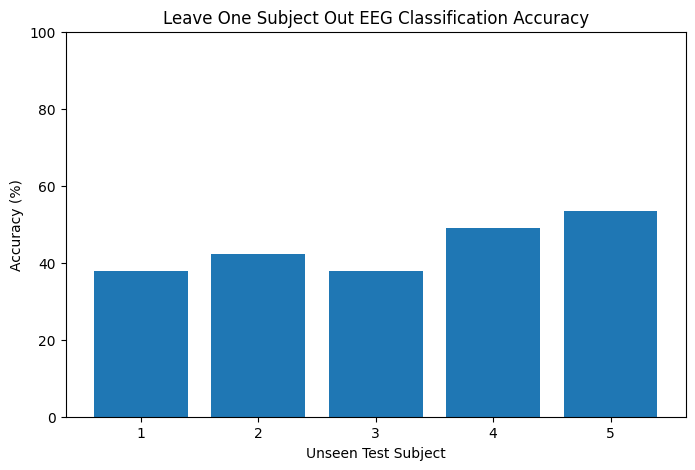

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(loso_results_df["Unseen Test Subject"], loso_results_df["Accuracy (%)"])
plt.xlabel("Unseen Test Subject")
plt.ylabel("Accuracy (%)")
plt.title("Leave One Subject Out EEG Classification Accuracy")
plt.ylim(0, 100)
plt.show()

## NeuroPilot v6 Results

The leave one subject out results showed that the classifier struggled to generalize to unseen participants.

Accuracy ranged from 37.78 percent to 53.33 percent when the model was trained on four subjects and tested on a completely new subject.

This was much lower than the subject specific cross validated results, where Subject 2 reached 86.67 percent mean accuracy.

These findings suggest that motor imagery EEG classification works better when models are trained and tested on the same participant, while generalizing to new participants is much more difficult.

This supports the idea that EEG based brain computer interface systems may require individual calibration before performing well.

## Best Subject Confusion Matrix

Subject 2 had the strongest cross validated performance, so I visualized its confusion matrix.

The confusion matrix shows how often the model correctly classified imagined left hand movement and imagined right hand movement.

Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower pass

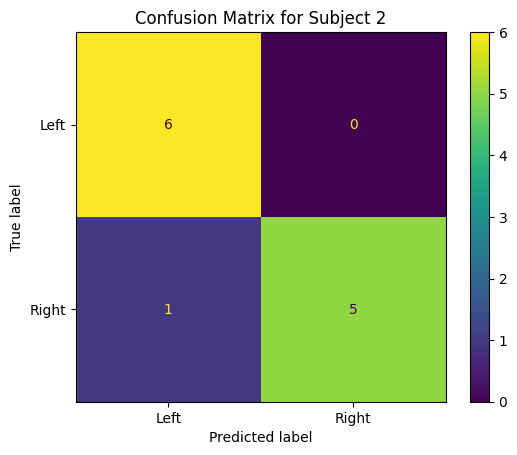

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

best_subject = 2
runs = [4, 8, 12]

files = eegbci.load_data(best_subject, runs)
raws = [read_raw_edf(f, preload=True) for f in files]
raw_best = concatenate_raws(raws)

eegbci.standardize(raw_best)
raw_best.set_montage(montage)
raw_best.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

events_best, event_id_best = mne.events_from_annotations(raw_best)

epochs_best = mne.Epochs(
    raw_best,
    events_best,
    dict(left=2, right=3),
    tmin=1.0,
    tmax=4.0,
    proj=True,
    baseline=None,
    preload=True
)

X_best = epochs_best.get_data()
y_best = epochs_best.events[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X_best,
    y_best,
    test_size=0.25,
    random_state=42,
    stratify=y_best
)

csp_best = CSP(n_components=4, reg=None, log=True, norm_trace=False)

clf_best = Pipeline([
    ("CSP", csp_best),
    ("LogisticRegression", LogisticRegression(max_iter=1000))
])

clf_best.fit(X_train, y_train)
y_pred = clf_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Left", "Right"]
)

disp.plot()
plt.title("Confusion Matrix for Subject 2")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix for Subject 2 showed strong classification performance.

The model correctly classified all 6 left hand imagery trials and 5 out of 6 right hand imagery trials.

Overall, the model correctly predicted 11 out of 12 test trials, giving a single split accuracy of 91.67 percent for Subject 2.

This supports the earlier finding that Subject 2 had the strongest motor imagery classification performance.

## Brain Electrode Map

This visualization shows the EEG electrode positions used in the recording.

The dataset uses 64 EEG channels placed across the scalp, allowing the model to analyze spatial patterns in brain activity.

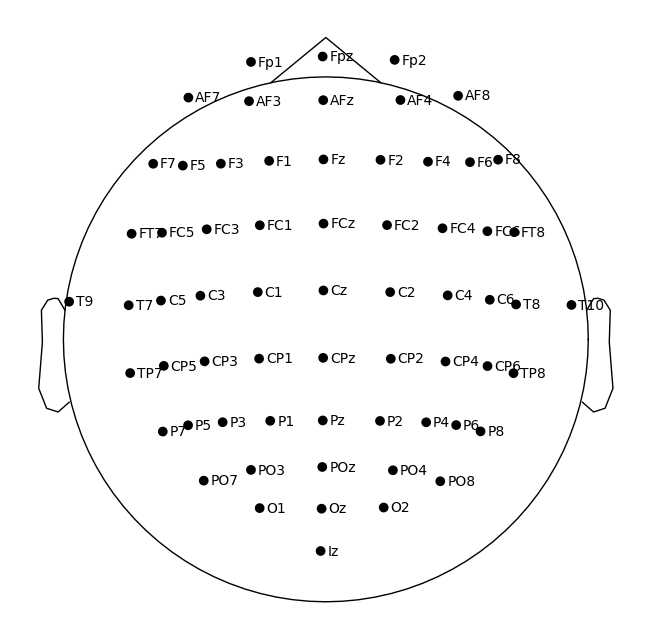

In [47]:
raw_best.copy().pick("eeg").plot_sensors(show_names=True)
plt.show()

## Electrode Map Interpretation

The electrode map shows the 64 EEG channels used in the dataset.

Because the electrodes are distributed across the scalp, the model can use spatial patterns of brain activity rather than relying on only one signal.

This is important for motor imagery classification because imagined movement can produce activity patterns across sensorimotor regions of the brain.

## CSP Pattern Visualization

This visualization shows the spatial EEG patterns learned by the Common Spatial Patterns method.

CSP helps identify electrode regions that are useful for separating imagined left hand movement from imagined right hand movement.

Brighter or darker regions indicate areas that contributed more strongly to the model’s separation of the two motor imagery classes.

NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


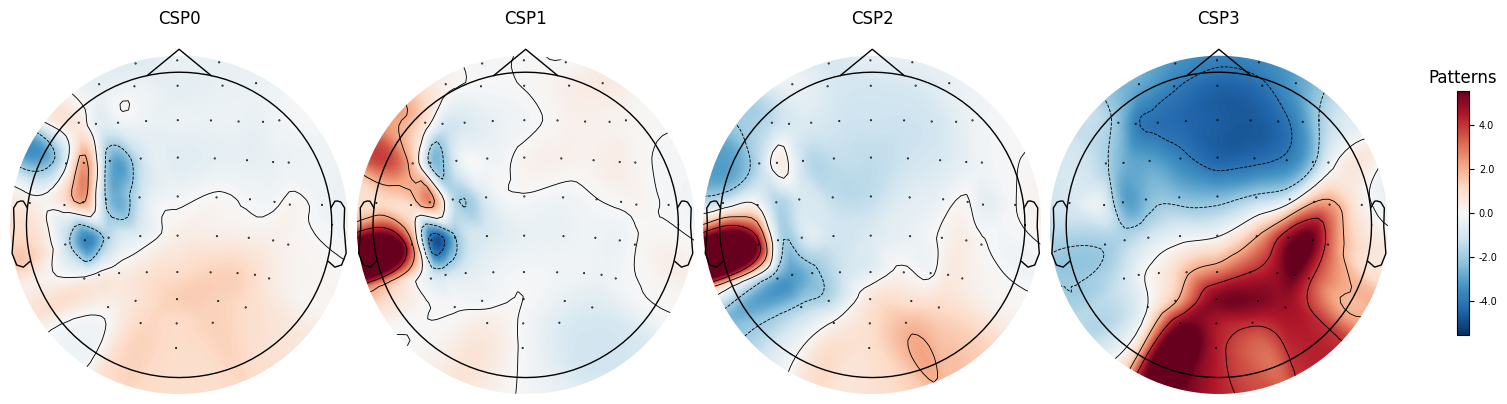

In [49]:
csp_best.plot_patterns(
    epochs_best.info,
    ch_type="eeg",
    components=[0, 1, 2, 3],
    units="Patterns",
    size=2.5
)

plt.show()

## CSP Pattern Interpretation

The CSP pattern visualization shows the spatial EEG patterns learned by the model.

Each map represents a different spatial pattern that helped separate imagined left hand movement from imagined right hand movement.

The strongest red and blue regions show electrode areas that contributed most to the classifier.

These results suggest that the model was not using random noise only. It learned spatial differences across the scalp that helped distinguish the two motor imagery conditions.

## Final Results

The first single subject model achieved 66.67 percent accuracy. When data from five subjects was combined into one multi subject model, accuracy dropped to 52.63 percent. Subject specific cross validation showed stronger performance, with Subject 2 reaching 86.67 percent mean accuracy and Subject 1 reaching 71.11 percent mean accuracy. The classifier comparison showed that logistic regression and SVM performed similarly overall. SVM slightly improved performance for some subjects, but logistic regression was more consistent across participants. Leave one subject out testing performed poorly, with accuracies ranging from 37.78 percent to 53.33 percent. This suggests that the model struggled to generalize to unseen participants. The confusion matrix for Subject 2 showed that the model correctly classified 11 out of 12 test trials in a single split.

## Final Conclusion

NeuroPilot demonstrated that EEG motor imagery classification can work using public brain signal data and basic machine learning methods. The strongest results appeared when models were trained and tested within the same participant. Performance dropped when data from multiple participants was combined, and leave one subject out testing showed that generalizing to new participants was difficult. This suggests that EEG based brain computer interface systems may require individual calibration before they perform well.
The project successfully demonstrates a full beginner neurotechnology workflow, including EEG loading, preprocessing, visualization, feature extraction, model training, model comparison, and brain based spatial pattern visualization.

## Future Improvements

Future versions of NeuroPilot could test more subjects, use more EEG runs, compare additional machine learning models, and explore deep learning approaches. The project could also test other EEG tasks, such as eyes open versus eyes closed, real movement versus imagined movement, or hands versus feet imagery. Another improvement would be turning the notebook into a simple web app where users can select a subject, run the model, and view the predicted brain state. A future hardware version could use a low cost EEG headset to classify live brain signals.